# Domain-wise WER Share of Best Dotting Models (length-unweighted / difficulty)

Each segment is a domain's **share of difficulty** (length-**unweighted**), drawn with the
same 100%-stacked bar as before so it drops straight into the paper.

* **This figure — WER share (length-unweighted):** each segment is a domain's share of the
  sum of **per-domain average WERs**. Every domain has the same number of test samples
  (500), so this share is proportional to per-domain WER and reflects **difficulty**, not
  length.
* **Superseded — error-count attribution (length-weighted):** the previous version, kept as
  `dotting_models_domain_errors_bar_outdated.ipynb`, sized each segment by a domain's share
  of the model's total error **count** (`wer_i x reference_word_count_i`). That is
  length-weighted, so a long-form domain (social media averages ~862 words/sample vs. ~16
  for KIND/Quran) dominated even at a modest per-word rate.

The right-hand number is the model's **overall macro WER** (mean of per-sample WER = the
Table 1 value), which restores absolute scale to the (otherwise relative) stacked bar.


In [1]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

Identical `MODELS` / domains / styling to the attribution notebook so the pair stays in sync.

In [2]:
def _find_package_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "dotting_models").is_dir():
            return parent
        if (parent / "tnqeet" / "dotting_models").is_dir():
            return parent / "tnqeet"
    raise RuntimeError(
        f"Could not locate the tnqeet package root (looked for a 'dotting_models/' "
        f"directory above {start}). Set PACKAGE_ROOT manually below."
    )

PACKAGE_ROOT = _find_package_root(Path.cwd())

MODELS = {
    "N-gram":      "dotting_models/ngrams/evaluation_results/test_dataset/beam_size_60/ngrams_8.json",
    "LSTM":        "dotting_models/sequence_labeling/evaluation_results/test_dataset/LSTM_layers_6_results.json",
    "Transformer": "dotting_models/transformer/evaluation_results/test_dataset/Transformer_layers_12_results.json",
    "CANINE-S":    "dotting_models/canine/evaluation_results/test_dataset/CANINE-canine-s_results.json",
    "Claude":      "dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/claude-sonnet-4.json",
    "Gemini":      "dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/gemini-2.5-flash-preview.json",
    "GPT-4o":      "dotting_models/llms/evaluation_results/test_dataset/fewshot_8/default_prompt/gpt-4o.json",
}

METRIC = "wer"                       # one of: "wer", "cer", "doer"
METRIC_LABEL = "Word Error Rate (%)"

# Same visual order as the attribution figure.
DOMAINS_ORDER = [
    "LLMs_abstracts", "tashkeela", "arasum", "iwslt", "social_media",
    "wasm", "poetry", "kind", "arabic_english_code_switching", "quran",
]
DOMAIN_LABELS = {
    "LLMs_abstracts": "LLM Abstracts", "tashkeela": "Tashkeela", "arasum": "AraSum",
    "iwslt": "IWSLT", "social_media": "Social Media", "wasm": "WASM", "poetry": "Poetry",
    "kind": "KIND", "arabic_english_code_switching": "Code-switch (Ar/En)", "quran": "Quran",
}
OUT_OF_DOMAIN = {"LLMs_abstracts", "arabic_english_code_switching", "kind"}

OUTPUT_DIR = PACKAGE_ROOT / "notebooks" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PDF = OUTPUT_DIR / "dotting_models_domain_errors_bar.pdf"

print(f"PACKAGE_ROOT = {PACKAGE_ROOT}")

PACKAGE_ROOT = /SLURM/home/slurm_majedalshaibani/Projects/tnqeet/tnqeet


## Load results

In [3]:
results = {}
for name, rel_path in MODELS.items():
    path = PACKAGE_ROOT / rel_path
    if not path.exists():
        raise FileNotFoundError(f"Missing results for {name!r}: {path}")
    with open(path, "r", encoding="utf-8") as f:
        results[name] = json.load(f)
    print(f"{name:14s} | n={len(results[name])}")

N-gram         | n=5000


LSTM           | n=5000


Transformer    | n=5000


CANINE-S       | n=5000


Claude         | n=5000


Gemini         | n=5000


GPT-4o         | n=5000


## Per-domain WER share (difficulty)

`share[d] = WER_d / sum_d WER_d`, where `WER_d` is the mean per-sample WER in domain `d`.
Shares sum to 100% per model. `overall_pct` is the overall **macro** WER (mean over all
5000 samples) — with 500 samples/domain this equals the unweighted mean of the ten
`WER_d`, and matches Table 1.

In [4]:
def wer_share(samples, metric="wer"):
    """Per-domain difficulty share plus overall macro WER (%)."""
    by_domain = defaultdict(list)
    for s in samples:
        by_domain[s["text_source"]].append(s[metric])
    per_domain_rate = {d: 100 * np.mean(v) for d, v in by_domain.items()}   # WER_d (%)
    denom = sum(per_domain_rate.values())
    share = {d: 100 * r / denom for d, r in per_domain_rate.items()}         # sums to 100
    overall = 100 * np.mean([s[metric] for s in samples])                    # macro (= Table 1)
    return {"share": share, "rate": per_domain_rate, "overall_pct": overall}

attribution = {name: wer_share(samples, METRIC) for name, samples in results.items()}

missing = [m for m in MODELS if m not in attribution]
if missing:
    raise RuntimeError(f"Configured but not loaded: {missing}. Re-run the 'Load results' cell.")

# Rows = domains, cols = models. Column of shares sums to 100; also show raw WER_d.
shares_df = pd.DataFrame(
    {m: [attribution[m]["share"].get(d, 0.0) for d in DOMAINS_ORDER] for m in MODELS},
    index=[DOMAIN_LABELS.get(d, d) for d in DOMAINS_ORDER],
)
shares_df.loc["TOTAL share"] = shares_df.sum(axis=0)
shares_df.loc[f"overall {METRIC.upper()} (%)"] = [attribution[m]["overall_pct"] for m in MODELS]
shares_df.round(2)

,N-gram,LSTM,Transformer,CANINE-S,Claude,Gemini,GPT-4o
LLM Abstracts,1.17,1.20,1.06,1.16,0.92,0.92,2.79
Tashkeela,0.54,1.32,0.76,0.94,6.97,7.74,10.18
AraSum,2.92,3.35,4.46,3.01,2.38,2.30,3.76
IWSLT,5.25,6.67,7.29,8.66,4.46,4.80,7.11
Social Media,9.23,11.06,12.06,11.28,6.33,7.61,9.50
WASM,8.03,9.28,9.11,10.68,9.04,7.45,8.56
Poetry,15.54,13.40,14.07,10.15,23.80,31.00,26.15
KIND,19.16,19.32,22.78,24.67,15.76,9.23,12.74
Code-switch (Ar/En),16.69,19.21,21.75,22.54,8.34,8.78,8.42
Quran,21.47,15.19,6.66,6.92,22.00,20.18,10.79


## Row-wise 100%-stacked bar (mirrors the attribution figure)

One row per model; segments sized by each domain's **share of difficulty**. Compare
directly against `dotting_models_domain_errors_bar_outdated.pdf` (the length-weighted
version): social media's segment collapses to its true difficulty weight, while
short-but-hard domains (KIND, Quran) grow.

findfont: Failed to find font weight 550, now using 400.


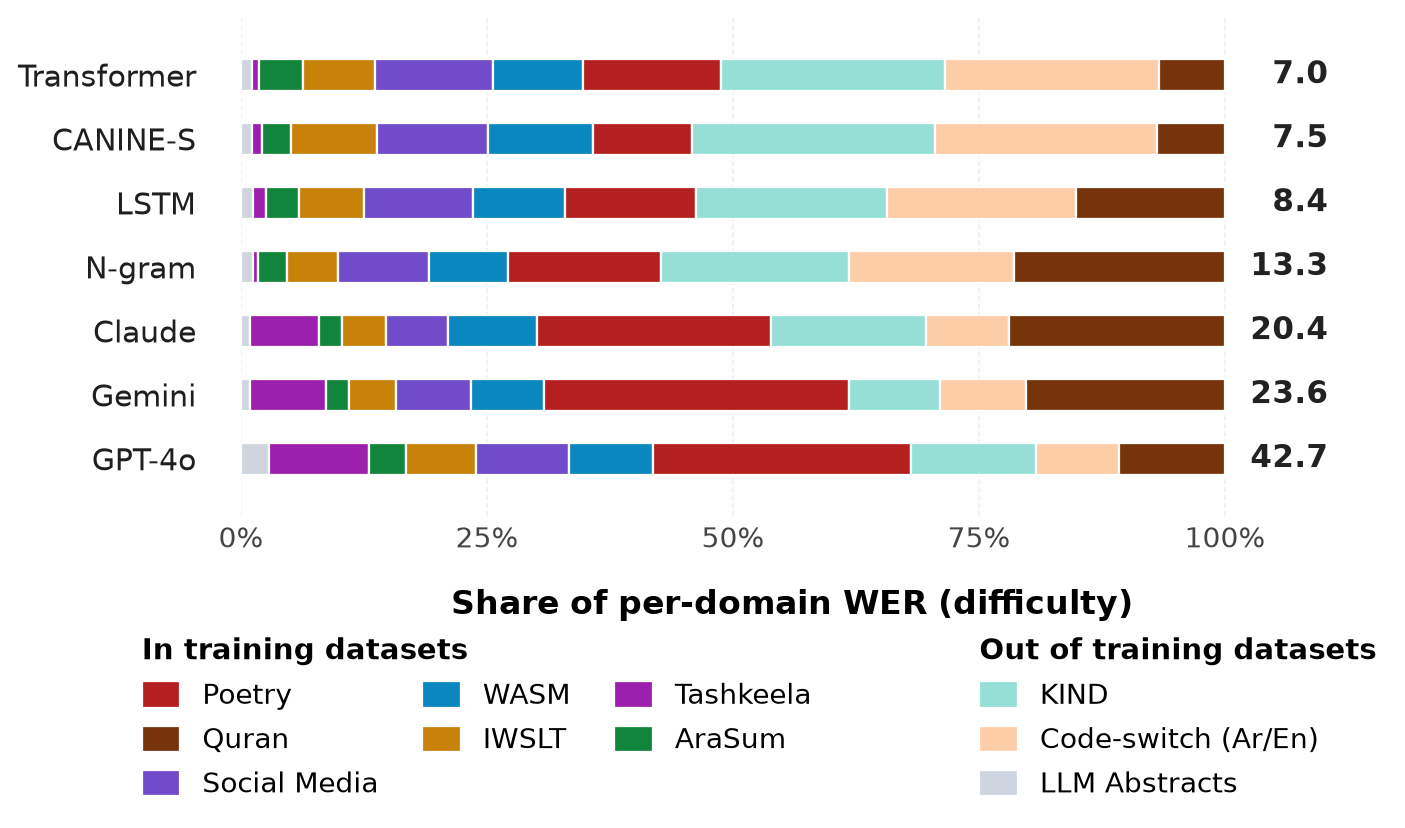

Saved: /SLURM/home/slurm_majedalshaibani/Projects/tnqeet/tnqeet/notebooks/figures/dotting_models_domain_errors_bar.pdf


In [5]:
from io import BytesIO
from IPython.display import Image, display
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 12, "axes.labelsize": 13, "xtick.labelsize": 11, "ytick.labelsize": 12,
    "legend.fontsize": 11, "legend.title_fontsize": 11.5,
    "axes.labelweight": "bold", "pdf.fonttype": 42, "ps.fonttype": 42,
})

# Same palette as the attribution figure (keep the two visually identical).
DOMAIN_COLORS = [
    "#94A3B8", "#C026D3", "#16A34A", "#F59E0B", "#8B5CF6",
    "#0EA5E9", "#DC2626", "#14B8A6", "#FB923C", "#92400E",
]
color_for = dict(zip(DOMAINS_ORDER, DOMAIN_COLORS))

def _blend(hex_color, target_rgb, amount):
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    tr, tg, tb = target_rgb
    return "#{:02X}{:02X}{:02X}".format(
        int(r + (tr - r) * amount), int(g + (tg - g) * amount), int(b + (tb - b) * amount))

IN_DARKEN, OOD_LIGHTEN = 0.18, 0.55
shade_for = {
    d: (_blend(color_for[d], (255, 255, 255), OOD_LIGHTEN) if d in OUT_OF_DOMAIN
        else _blend(color_for[d], (0, 0, 0), IN_DARKEN))
    for d in DOMAINS_ORDER
}

models_sorted = sorted(MODELS, key=lambda m: attribution[m]["overall_pct"])
y_base = np.arange(len(models_sorted))

fig, ax = plt.subplots(figsize=(7.9, 3.6))
fig.patch.set_facecolor("white")

left = np.zeros(len(models_sorted))
for domain in DOMAINS_ORDER:
    values = np.array([attribution[m]["share"].get(domain, 0.0) for m in models_sorted])
    ax.barh(y_base, values, left=left, height=0.50,
            color=shade_for[domain], edgecolor="white", linewidth=0.9)
    left += values

WER_RIGHT_X = 110.5
for i, m in enumerate(models_sorted):
    ax.text(WER_RIGHT_X, y_base[i], f"{attribution[m]['overall_pct']:.1f}",
            ha="right", va="center", fontsize=12.5, fontweight="bold", color="#222222")

ax.set_xlim(0, 112)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], color="#444444")
ax.set_yticks(y_base)
ax.set_yticklabels(models_sorted)
ax.invert_yaxis()
ax.set_xlabel("Share of per-domain WER (difficulty)", labelpad=14)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="x", length=0, pad=4)
ax.tick_params(axis="y", length=0, pad=18)
for label in ax.get_yticklabels():
    label.set_color("#1F1F1F"); label.set_fontweight(550); label.set_fontsize(12)
ax.grid(True, axis="x", alpha=0.22, linestyle="--", linewidth=0.6)
ax.set_axisbelow(True)
ax.margins(y=0.10)

mean_share = {d: float(np.mean([attribution[m]["share"].get(d, 0.0) for m in MODELS]))
              for d in DOMAINS_ORDER}
in_domain = sorted([d for d in DOMAINS_ORDER if d not in OUT_OF_DOMAIN], key=lambda d: -mean_share[d])
ood_domain = sorted([d for d in DOMAINS_ORDER if d in OUT_OF_DOMAIN], key=lambda d: -mean_share[d])

def _patch(d):
    return Patch(facecolor=shade_for[d], edgecolor="white", linewidth=0.9,
                 label=DOMAIN_LABELS.get(d, d))

LEGEND_Y = -0.22
leg_in = ax.legend(handles=[_patch(d) for d in in_domain], title="In training datasets",
                   loc="upper left", bbox_to_anchor=(-0.10, LEGEND_Y), ncol=3, frameon=False,
                   handlelength=1.4, handleheight=1.1, columnspacing=1.6, labelspacing=0.55,
                   borderaxespad=0.0)
leg_in.get_title().set_fontweight("bold")
leg_in._legend_box.align = "left"
ax.add_artist(leg_in)

leg_ood = ax.legend(handles=[_patch(d) for d in ood_domain], title="Out of training datasets",
                    loc="upper left", bbox_to_anchor=(0.66, LEGEND_Y), ncol=1, frameon=False,
                    handlelength=1.4, handleheight=1.1, labelspacing=0.55, borderaxespad=0.0)
leg_ood.get_title().set_fontweight("bold")
leg_ood._legend_box.align = "left"

extras = (leg_in, leg_ood)
fig.savefig(OUTPUT_PDF, format="pdf", bbox_inches="tight", bbox_extra_artists=extras, pad_inches=0.10)
buf = BytesIO()
fig.savefig(buf, format="png", dpi=180, bbox_inches="tight", bbox_extra_artists=extras, pad_inches=0.10)
plt.close(fig)
display(Image(buf.getvalue()))
print(f"Saved: {OUTPUT_PDF}")

## Difficulty vs. error share: the rankings disagree

Quantifies the gap for one model: each domain's per-domain WER (difficulty) and its
length-weighted error share (the attribution figure) rarely agree. This table is the
direct rebuttal evidence.

In [6]:
def error_share(samples, metric="wer"):
    by_err, total = defaultdict(float), 0.0
    for s in samples:
        units = max(1, len(s["original_dotted_text"].split()) if metric == "wer"
                    else len(s["original_dotted_text"]))
        e = s[metric] * units
        by_err[s["text_source"]] += e
        total += e
    return {d: 100 * e / total for d, e in by_err.items()}

MODEL_TO_INSPECT = "Transformer"
esh = error_share(results[MODEL_TO_INSPECT], METRIC)
cmp_df = pd.DataFrame({
    "per-domain WER (%)": [attribution[MODEL_TO_INSPECT]["rate"].get(d, np.nan) for d in DOMAINS_ORDER],
    "error share (%)":    [esh.get(d, 0.0) for d in DOMAINS_ORDER],
    "avg words/sample":   [np.mean([len(s["original_dotted_text"].split())
                                     for s in results[MODEL_TO_INSPECT]
                                     if s["text_source"] == d]) for d in DOMAINS_ORDER],
}, index=[DOMAIN_LABELS[d] for d in DOMAINS_ORDER])
cmp_df["difficulty rank"] = cmp_df["per-domain WER (%)"].rank(ascending=False).astype(int)
cmp_df["share rank"] = cmp_df["error share (%)"].rank(ascending=False).astype(int)
print(f"Model: {MODEL_TO_INSPECT}")
cmp_df.sort_values("per-domain WER (%)", ascending=False).round(2)

Model: Transformer


,per-domain WER (%),error share (%),avg words/sample,difficulty rank,share rank
KIND,15.87,2.37,15.65,1,5
Code-switch (Ar/En),15.15,3.39,22.20,2,4
Poetry,9.80,13.41,138.59,3,2
Social Media,8.40,66.16,861.77,4,1
WASM,6.34,1.21,19.56,5,6
IWSLT,5.08,0.95,19.13,6,7
Quran,4.64,0.80,18.19,7,8
AraSum,3.11,10.87,370.94,8,3
LLM Abstracts,0.74,0.56,82.22,9,9
Tashkeela,0.53,0.27,54.75,10,10
